In [7]:
import pandas as pd
heart_disease = pd.read_csv("iris.csv")

In [13]:
import pandas as pd

heart_disease = pd.read_csv("iris.csv", header=None)

heart_disease.columns = [
    "sepal_length",
    "sepal_width",
    "petal_length",
    "petal_width",
    "target"
]

X = heart_disease.drop("target", axis=1)
y = heart_disease["target"]

print(X.head())
print(y.head())

   sepal_length  sepal_width  petal_length  petal_width
0           5.1          3.5           1.4          0.2
1           4.9          3.0           1.4          0.2
2           4.7          3.2           1.3          0.2
3           4.6          3.1           1.5          0.2
4           5.0          3.6           1.4          0.2
0    Iris-setosa
1    Iris-setosa
2    Iris-setosa
3    Iris-setosa
4    Iris-setosa
Name: target, dtype: str


In [14]:
print(heart_disease.columns)

Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'target'], dtype='str')


In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier
clf = RandomForestClassifier(random_state=42)
scores = cross_val_score(clf, X, y, cv=5)
print(scores)
print("Average:", scores.mean())

[0.96666667 0.96666667 0.93333333 0.96666667 1.        ]
Average: 0.9666666666666668


In [16]:
np.mean(scores)

np.float64(0.9666666666666668)

In [19]:
from sklearn.model_selection import train_test_split

In [18]:
from sklearn.metrics import roc_curve

In [20]:
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2,random_state=42)

In [22]:

from sklearn.ensemble import RandomForestClassifier

In [24]:
clf.fit(X_train, y_train)
y_probs = clf.predict_proba(X_test)[:, 1]
print(y_probs[:10])
print(len(y_probs))

[0.99 0.   0.03 1.   0.87 0.   1.   0.08 0.86 1.  ]
30


In [25]:
clf = RandomForestClassifier(random_state=42)

In [30]:
clf.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [31]:
y_probs = clf.predict_proba(X_test)

In [ ]:
y_probs_positive = y_probs[:, 1]
print(y_probs_positive[:10])

[0.99 0.   0.03 1.   0.87 0.   1.   0.08 0.86 1.  ]


In [36]:
y_test_binary = (y_test == "Iris-virginica").astype(int)
y_probs_positive = clf.predict_proba(X_test)[:, 2]
fpr, tpr, thresholds = roc_curve(y_test_binary, y_probs_positive)
print(fpr)
print(tpr)

[0.         0.         0.         0.         0.         0.21052632
 1.        ]
[0.         0.27272727 0.45454545 0.81818182 1.         1.
 1.        ]


In [35]:
print(clf.classes_)

['Iris-setosa' 'Iris-versicolor' 'Iris-virginica']


In [38]:
fpr, tpr, thresholds = roc_curve(y_test_binary, y_probs_positive)
fpr

array([0.        , 0.        , 0.        , 0.        , 0.        ,
       0.21052632, 1.        ])

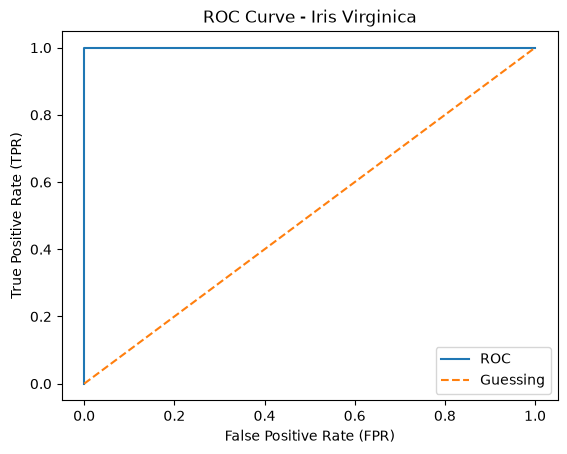

In [39]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve
y_test_binary = (y_test == "Iris-virginica").astype(int)
y_probs_positive = clf.predict_proba(X_test)[:, 2]
fpr, tpr, thresholds = roc_curve(y_test_binary, y_probs_positive)
def plot_roc_curve(fpr, tpr):
    plt.plot(fpr, tpr, label="ROC")
    plt.plot([0, 1], [0, 1], linestyle="--", label="Guessing")
    plt.xlabel("False Positive Rate (FPR)")
    plt.ylabel("True Positive Rate (TPR)")
    plt.title("ROC Curve - Iris Virginica")
    plt.legend()
    plt.show()
plot_roc_curve(fpr, tpr)

In [42]:
from sklearn.metrics import roc_auc_score
y_test_binary = (y_test == "Iris-virginica").astype(int)
y_probs_positive = clf.predict_proba(X_test)[:, 2]
roc_auc_score(y_test_binary, y_probs_positive)


1.0

----------------------------------

1.1 The Problem With a Single Test Set

Repeatedly using the test set to adjust the parameters of the model for fine-tuning the modelâ€™s performance leads to an overestimation of the performance of the model due to a leakage of information in the model. 

-----------------------

1.2 The Three-Way Split

The dataset is split into training, validation, and test subsets. The test set is utilized only one time for the final assessment. 

--------------------------------

1.3 Creating the Split in Code

In [3]:
import pandas as pd
iris = pd.read_csv("iris.csv", header=None)

iris.columns = [
    "sepal_length",
    "sepal_width",
    "petal_length",
    "petal_width",
    "target"
]

In [4]:
X = iris.drop("target", axis=1)
y = iris["target"]

In [5]:
from sklearn.model_selection import train_test_split
X_temp, X_test, y_temp, y_test = train_test_split(X, y,test_size=0.2,random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp,test_size=0.25,random_state=42)

In [6]:
print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

(90, 4)
(30, 4)
(30, 4)
